# ViT pruning — thesis figures

Compact version of the layer-metrics viz, focused on figures that earn their place in the thesis chapter. Seven figures, each answering one question:

1. **Master heatmap** — full result matrix, all algorithms × all block widths
2. **Block-width sweep (score)** — where does each algorithm pay off?
3. **Block-width sweep (accuracy)** — at what block width does pruning destroy the model?
4. **Score↔accuracy tradeoff** — overlay of the two above, the thesis money figure
5. **Per-layer comparison at narrow vs wide blocks (1×2 + 1×16)** — does the algorithm ranking depend on layer type?
6. **Score → rel_error validation** — does the cheap metric track the real one?
7. **Pruning time cost** — what does GA-TETRIS cost wall-clock-wise?

All data comes from CSVs in `benchmark_csvs_vit/`. No scrapbook reads, no executed-notebook reads.

## Setup

In [10]:
%load_ext autoreload
%autoreload 2

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display

OUTPUT_FOLDER = "benchmark_csvs_vit_test_vit3.r160_in1k_full_grid_iters"

LAYER_TYPES = ["attn.qkv", "attn.proj", "mlp.fc1", "mlp.fc2"]
LAYER_GROUP = {"attn.qkv": "Attention", "attn.proj": "Attention",
               "mlp.fc1": "MLP", "mlp.fc2": "MLP"}

# Consistent colors per algorithm
ALG_COLORS = {
    "GA-TETRIS":             "#d62728",
    "Original TETRIS":       "#1f77b4",
    "Sort-by-Norm":          "#2ca02c",
    "Block-Wanda":           "#ff7f0e",
    "Random":                "#9467bd",
    "Random-Swaps":          "#8c564b",
    "Random-Swaps (sorted)": "#17becf",
    "No prune":              "#7f7f7f",
}
def alg_color(alg):
    return ALG_COLORS.get(alg, "#555555")

LAYER_COLORS = {
    "attn.qkv":  "#1f77b4",
    "attn.proj": "#d62728",
    "mlp.fc1":   "#9467bd",
    "mlp.fc2":   "#8c564b",
}
def layer_color(lt):
    return LAYER_COLORS.get(lt, "#555555")

# Display order for algorithms in plots — best at top
ALG_ORDER = ["GA-TETRIS", "Original TETRIS", "Sort-by-Norm",
             "Random-Swaps (sorted)", "Random-Swaps", "Block-Wanda"]
def alg_sort_key(a):
    return ALG_ORDER.index(a) if a in ALG_ORDER else 99

import os
FIGURES_DIR = "../../thesis/images"
os.makedirs(FIGURES_DIR, exist_ok=True)

def save_fig(fig, name):
    """Save figure as PDF in the figures directory."""
    path = os.path.join(FIGURES_DIR, f"{name}.pdf")
    fig.savefig(path, bbox_inches="tight")
    print(f"Saved {path}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load

In [11]:
_LAYER_RE = re.compile(r"blocks\.(\d+)\.(.+)")

def parse_layer_name(name):
    m = _LAYER_RE.match(name)
    return (None, name) if not m else (int(m.group(1)), m.group(2))


csv_files = sorted(glob.glob(os.path.join(OUTPUT_FOLDER, "layer_metrics_*.csv")))
print(f"Found {len(csv_files)} CSVs.")

dfs = [pd.read_csv(f) for f in csv_files]
df = pd.concat(dfs, ignore_index=True)

parsed = df["layer_name"].apply(parse_layer_name)
df["layer_idx"]  = parsed.apply(lambda x: x[0])
df["layer_type"] = parsed.apply(lambda x: x[1])
df = df[df["layer_idx"].notna()].copy()
df["layer_idx"] = df["layer_idx"].astype(int)

df["retained_frac"]     = df["retained_wanda_mass"] / df["total_wanda_mass"]
df["pruned_wanda_mass"] = df["total_wanda_mass"] - df["retained_wanda_mass"]
df["rel_error_weights"] = df["pruned_weight_l1"] / df["total_weight_l1"]
df["block_size"]        = df["block_rows"].astype(str) + "x" + df["block_cols"].astype(str)
df["block_width"]       = df["block_cols"]
df["layer_group"]       = df["layer_type"].map(LAYER_GROUP)

# Promote sort_start to a separate algorithm name
if "sort_start" in df.columns:
    is_rs = df["algorithm"].isin(["random_swaps", "random_swaps_find_mask"])
    df.loc[is_rs & (df["sort_start"] == True), "algorithm"] = (
        df.loc[is_rs & (df["sort_start"] == True), "algorithm"] + "_sort_start"
    )

ALG_DISPLAY = {
    "our_tetris":                       "GA-TETRIS",
    "original_tetris":                  "Original TETRIS",
    "block_wanda":                      "Block-Wanda",
    "block_only":                       "Block-Wanda",
    "sort_columns_by_norm":             "Sort-by-Norm",
    "random_permutation_pruning":       "Random",
    "random_swaps":                     "Random-Swaps",
    "random_swaps_find_mask":           "Random-Swaps",
    "random_swaps_sort_start":          "Random-Swaps (sorted)",
    "random_swaps_find_mask_sort_start":"Random-Swaps (sorted)",
    "no_prune":                         "No prune",
}
df["algorithm"] = df["algorithm"].map(ALG_DISPLAY).fillna(df["algorithm"])

print(f"Algorithms:    {sorted(df.algorithm.unique())}")
print(f"Block widths:  {sorted(df.block_cols.unique())}")
print(f"Sparsities:    {sorted(df.sparsity.unique())}")
print(f"Total rows:    {len(df)}")

# Default sparsity used by every figure below
SPARSITY = 0.5
df_s = df[df["sparsity"] == SPARSITY].copy()
print(f"\nUsing sparsity={SPARSITY}: {len(df_s)} rows")


Found 86 CSVs.
Algorithms:    ['GA-TETRIS', 'Original TETRIS', 'Random-Swaps', 'Random-Swaps (sorted)']
Block widths:  [np.int64(8)]
Sparsities:    [np.float64(0.5)]
Total rows:    3096

Using sparsity=0.5: 3096 rows


Iter sweep:   [np.int64(1), np.int64(3), np.int64(5), np.int64(10), np.int64(20)] iter values × [np.int64(100)] swap values
Swaps sweep:  [np.int64(10)] iter values × [np.int64(0), np.int64(10), np.int64(20), np.int64(50), np.int64(100)] swap values


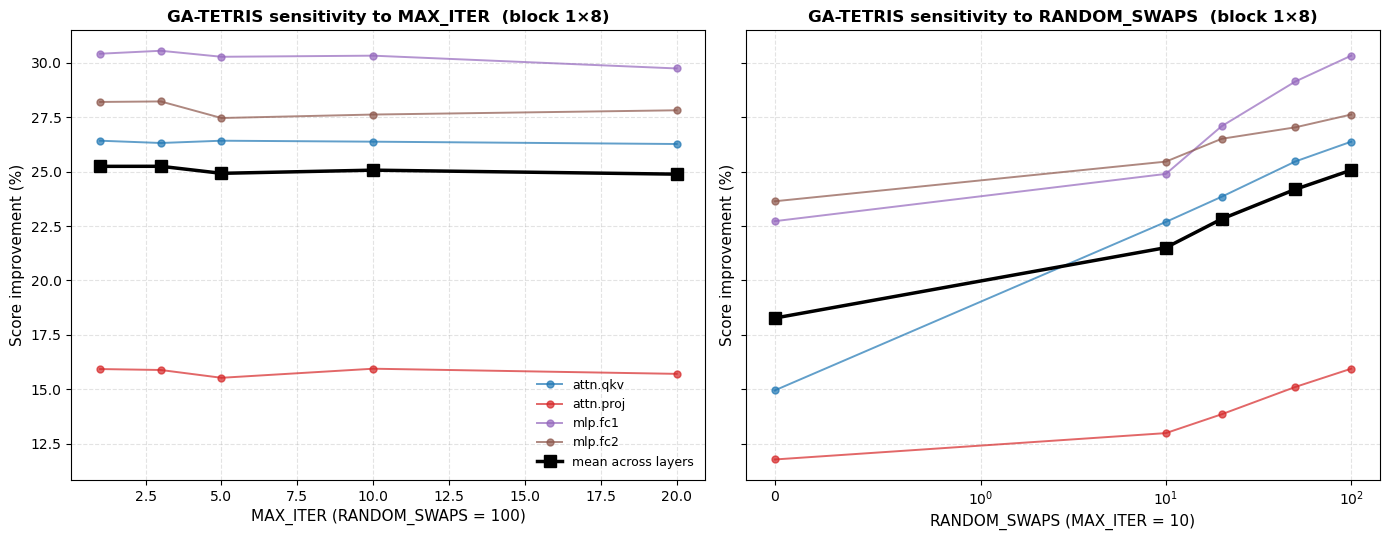


=== Wall-clock cost per (MAX_ITER, RANDOM_SWAPS) ===
                        mean     sum
max_iter random_swaps               
1        0             0.003   0.326
         10            0.039   4.225
         20            0.075   8.140
         50            0.183  19.771
         100           0.365  39.370
3        0             0.006   0.672
         10            0.042   4.587
         20            0.079   8.508
         50            0.189  20.414
         100           0.370  39.963
5        0             0.009   1.009
         10            0.045   4.912
         20            0.082   8.841
         50            0.191  20.601
         100           0.375  40.518
10       0             0.017   1.847
         10            0.054   5.779
         20            0.089   9.650
         50            0.197  21.320
         100           0.383  41.385
20       0             0.033   3.511
         10            0.069   7.436
         20            0.106  11.406
         50          

In [12]:
# ============================================================================
# Hyperparameter sensitivity: MAX_ITER and RANDOM_SWAPS for GA-TETRIS
# ============================================================================
SWEEP_BLOCK_W = 8
SWEEP_ALG     = "GA-TETRIS"

# All GA-TETRIS data at the sweep block width
sweep_df = df_s[(df_s.algorithm == SWEEP_ALG) &
                (df_s.block_cols == SWEEP_BLOCK_W)].copy()

# Identify the two sweeps:
#   max_iter sweep at fixed RANDOM_SWAPS=100
#   random_swaps sweep at fixed MAX_ITER=10
iter_sweep  = sweep_df[sweep_df["random_swaps"] == 100].copy()
swaps_sweep = sweep_df[sweep_df["max_iter"] == 10].copy()

print(f"Iter sweep:   {sorted(iter_sweep['max_iter'].unique())} iter values "
      f"× {sorted(iter_sweep['random_swaps'].unique())} swap values")
print(f"Swaps sweep:  {sorted(swaps_sweep['max_iter'].unique())} iter values "
      f"× {sorted(swaps_sweep['random_swaps'].unique())} swap values")


def plot_sweep(ax, sweep_data, x_col, x_label, log_x=False):
    """One sweep curve per layer type, plus a thick mean line."""
    layer_types_present = [lt for lt in LAYER_TYPES if lt in sweep_data.layer_type.unique()]

    # Per-layer-type curves (thin)
    for lt in layer_types_present:
        sub = (sweep_data[sweep_data.layer_type == lt]
               .groupby(x_col)["score_improvement_pct"].mean()
               .reset_index().sort_values(x_col))
        ax.plot(sub[x_col], sub["score_improvement_pct"],
                marker="o", linewidth=1.4, markersize=5,
                color=layer_color(lt), label=lt, alpha=0.7)

    # Overall mean (thick black)
    overall = (sweep_data.groupby(x_col)["score_improvement_pct"].mean()
               .reset_index().sort_values(x_col))
    ax.plot(overall[x_col], overall["score_improvement_pct"],
            marker="s", linewidth=2.5, markersize=8,
            color="black", label="mean across layers", zorder=5)

    if log_x:
        ax.set_xscale("symlog", linthresh=1)  # symlog handles 0 in swaps sweep
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel("Score improvement (%)", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.35)


fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

plot_sweep(axes[0], iter_sweep,  "max_iter",
           "MAX_ITER (RANDOM_SWAPS = 100)")
axes[0].set_title(f"GA-TETRIS sensitivity to MAX_ITER  (block 1×{SWEEP_BLOCK_W})",
                  fontsize=12, fontweight="bold")
axes[0].legend(loc="lower right", frameon=False, fontsize=9)

plot_sweep(axes[1], swaps_sweep, "random_swaps",
           "RANDOM_SWAPS (MAX_ITER = 10)", log_x=True)
axes[1].set_title(f"GA-TETRIS sensitivity to RANDOM_SWAPS  (block 1×{SWEEP_BLOCK_W})",
                  fontsize=12, fontweight="bold")

fig.tight_layout()
plt.show()


# Also print the wall-clock cost — useful for thesis caption
print("\n=== Wall-clock cost per (MAX_ITER, RANDOM_SWAPS) ===")
cost = (sweep_df.groupby(["max_iter", "random_swaps"])["total_time_sec"]
        .agg(["mean", "sum"]).round(3))
print(cost)

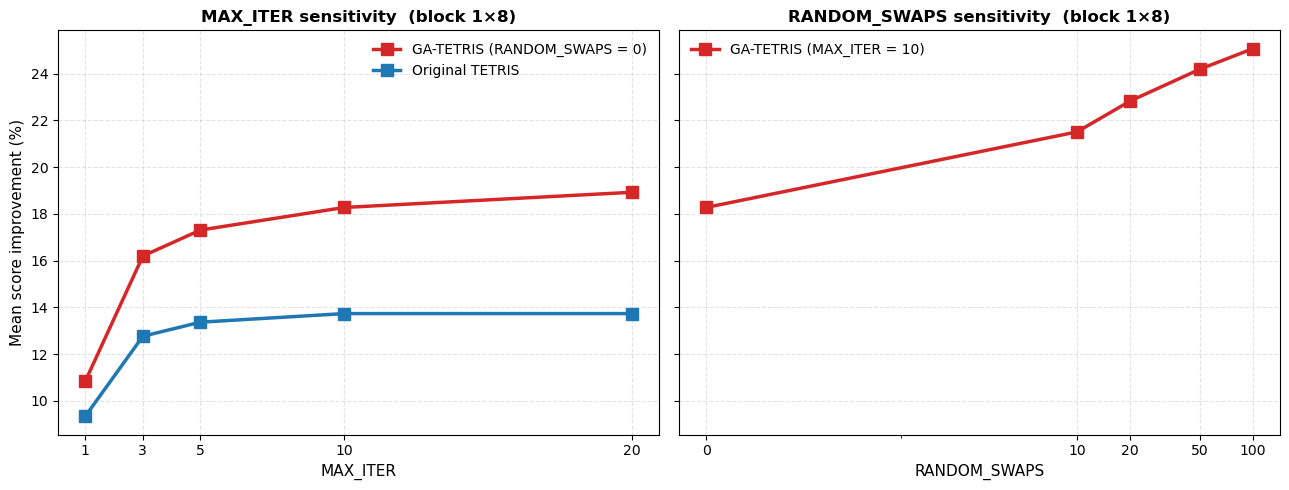


=== Wall-clock cost (GA-TETRIS, block 1×8) ===
                       mean_per_layer  total_across_layers
max_iter random_swaps                                     
1        0                      0.003                0.326
         10                     0.039                4.225
         20                     0.075                8.140
         50                     0.183               19.771
         100                    0.365               39.370
3        0                      0.006                0.672
         10                     0.042                4.587
         20                     0.079                8.508
         50                     0.189               20.414
         100                    0.370               39.963
5        0                      0.009                1.009
         10                     0.045                4.912
         20                     0.082                8.841
         50                     0.191               20.601
        

In [13]:
from matplotlib.ticker import FuncFormatter

SWEEP_BLOCK_W = 8

ga_df = df_s[(df_s.algorithm == "GA-TETRIS") &
             (df_s.block_cols == SWEEP_BLOCK_W)].copy()
ot_df = df_s[(df_s.algorithm == "Original TETRIS") &
             (df_s.block_cols == SWEEP_BLOCK_W)].copy()

iter_sweep  = ga_df[ga_df["random_swaps"] == 0].copy()
swaps_sweep = ga_df[ga_df["max_iter"] == 10].copy()


def plot_mean(ax, data, x_col, label, color, marker="s", linestyle="-"):
    agg = (data.groupby(x_col)["score_improvement_pct"].mean()
                .reset_index().sort_values(x_col))
    ax.plot(agg[x_col], agg["score_improvement_pct"],
            marker=marker, linewidth=2.5, markersize=8,
            color=color, linestyle=linestyle, label=label)


fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Left: MAX_ITER for both algorithms
plot_mean(axes[0], iter_sweep, "max_iter",
          "GA-TETRIS (RANDOM_SWAPS = 0)", alg_color("GA-TETRIS"))
plot_mean(axes[0], ot_df,      "max_iter",
          "Original TETRIS", alg_color("Original TETRIS"))
axes[0].set_xticks(sorted(iter_sweep.max_iter.unique()))
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}"))
axes[0].set_xlabel("MAX_ITER", fontsize=11)
axes[0].set_ylabel("Mean score improvement (%)", fontsize=11)
axes[0].set_title(f"MAX_ITER sensitivity  (block 1×{SWEEP_BLOCK_W})",
                  fontsize=12, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.35)
axes[0].legend(frameon=False, fontsize=10)

# Right: RANDOM_SWAPS for GA-TETRIS only
plot_mean(axes[1], swaps_sweep, "random_swaps",
          "GA-TETRIS (MAX_ITER = 10)", alg_color("GA-TETRIS"))
axes[1].set_xscale("symlog", linthresh=1)
axes[1].set_xticks(sorted(swaps_sweep.random_swaps.unique()))
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}"))
axes[1].xaxis.set_minor_formatter(FuncFormatter(lambda x, _: ""))
axes[1].set_xlabel("RANDOM_SWAPS", fontsize=11)
axes[1].set_title(f"RANDOM_SWAPS sensitivity  (block 1×{SWEEP_BLOCK_W})",
                  fontsize=12, fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.35)
axes[1].legend(frameon=False, fontsize=10)

fig.tight_layout()
plt.show()


# Wall-clock cost per (MAX_ITER, RANDOM_SWAPS) for GA-TETRIS at this block width
print(f"\n=== Wall-clock cost (GA-TETRIS, block 1×{SWEEP_BLOCK_W}) ===")
cost = (ga_df.groupby(["max_iter", "random_swaps"])["total_time_sec"]
        .agg(mean_per_layer="mean", total_across_layers="sum").round(3))
print(cost)

print(f"\n=== Wall-clock cost (Original TETRIS, block 1×{SWEEP_BLOCK_W}) ===")
cost_ot = (ot_df.groupby(["max_iter"])["total_time_sec"]
           .agg(mean_per_layer="mean", total_across_layers="sum").round(4))
print(cost_ot)

In [14]:
import re

# Reload the GA-TETRIS data with inner_refine parsed from filename
gt_files = sorted(glob.glob(os.path.join(OUTPUT_FOLDER, "layer_metrics_our_tetris_*.csv")))

frames = []
for f in gt_files:
    m = re.search(r"_innerref_(\d+)", os.path.basename(f))
    if not m:
        continue
    sub = pd.read_csv(f)
    sub["inner_refine"] = int(m.group(1))
    frames.append(sub)

if not frames:
    raise RuntimeError("No GA-TETRIS CSVs with innerref in filename found")

df_grid = pd.concat(frames, ignore_index=True)

# Filter to the grid sweep — block 1×8, the actual grid configs
df_grid = df_grid[(df_grid.block_cols == 8) & (df_grid.sparsity == 0.5)]

# Aggregate to one row per (mi, rs, ir)
grid = (df_grid.groupby(["max_iter", "random_swaps", "inner_refine"])
              [["score_improvement_pct", "total_time_sec"]]
              .mean()
              .reset_index()
              .sort_values("score_improvement_pct", ascending=False))

print(f"Grid cells: {len(grid)}")
print(grid.to_string(index=False))

Grid cells: 75
 max_iter  random_swaps  inner_refine  score_improvement_pct  total_time_sec
       20           100             3              26.800255        0.533990
        3           100             3              26.701963        0.501323
       10           100             3              26.635424        0.518585
        5           100             3              26.566542        0.510930
       10           100             2              26.325134        0.386840
       20           100             2              26.236582        0.394434
        1           100             3              26.191412        0.502381
        5           100             2              26.103975        0.379289
        3           100             2              26.028105        0.376769
        5            50             3              25.839347        0.259471
        3            50             3              25.818904        0.257646
       20            50             3              25.714171 

Saved ../../thesis/images/vit3_tetrises_iter_sweep.pdf


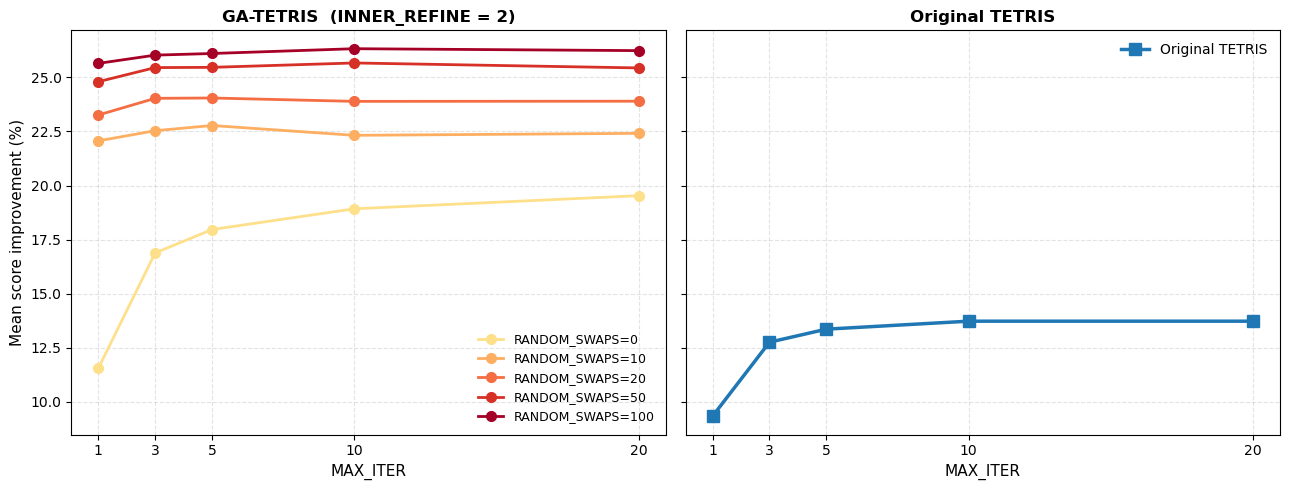

In [15]:
# Filter: GA-TETRIS at INNER_REFINE=2
ga = grid[grid.inner_refine == 2]

ot_iter = df_s[(df_s.algorithm == "Original TETRIS") &
               (df_s.block_cols == 8)].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# ----------------------------------------------------------------------------
# LEFT PANEL: GA-TETRIS — score vs MAX_ITER, line per RANDOM_SWAPS
# ----------------------------------------------------------------------------
rs_colors = {
    0:   "#fee08b",
    10:  "#fdae61",
    20:  "#f46d43",
    50:  "#d73027",
    100: "#a50026",
}
for rs in sorted(ga.random_swaps.unique()):
    sub = ga[ga.random_swaps == rs].sort_values("max_iter")
    axes[0].plot(sub.max_iter, sub.score_improvement_pct,
                 marker="o", linewidth=2, markersize=7,
                 color=rs_colors[rs], label=f"RANDOM_SWAPS={rs}")

axes[0].set_xticks(sorted(ga.max_iter.unique()))
axes[0].set_xlabel("MAX_ITER", fontsize=11)
axes[0].set_ylabel("Mean score improvement (%)", fontsize=11)
axes[0].set_title("GA-TETRIS  (INNER_REFINE = 2)",
                  fontsize=12, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.35)
axes[0].legend(frameon=False, fontsize=9, loc="lower right")

# ----------------------------------------------------------------------------
# RIGHT PANEL: Original TETRIS — score vs MAX_ITER
# ----------------------------------------------------------------------------
agg_ot = (ot_iter.groupby("max_iter")["score_improvement_pct"].mean()
                  .reset_index().sort_values("max_iter"))
axes[1].plot(agg_ot.max_iter, agg_ot.score_improvement_pct,
             marker="s", linewidth=2.5, markersize=8,
             color="#1f77b4", label="Original TETRIS")

axes[1].set_xticks(sorted(agg_ot.max_iter.unique()))
axes[1].set_xlabel("MAX_ITER", fontsize=11)
axes[1].set_title("Original TETRIS",
                  fontsize=12, fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.35)
axes[1].legend(frameon=False, fontsize=10)

fig.tight_layout()
save_fig(fig, "vit3_tetrises_iter_sweep")
plt.show()

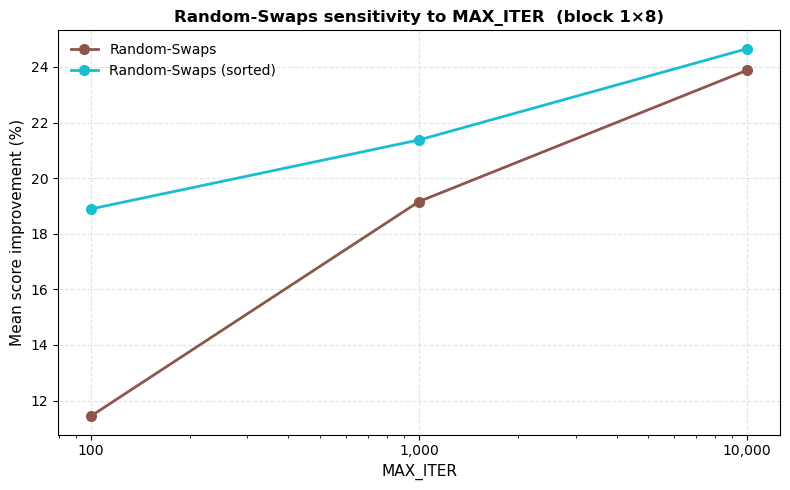

In [25]:
# Just MAX_ITER on x, two lines for sort_start True/False
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

rs_df = df[(df.algorithm.isin(["Random-Swaps", "Random-Swaps (sorted)"])) &
           (df.block_cols == 8) & (df.sparsity == 0.5)].copy()

fig, ax = plt.subplots(figsize=(8, 5))
for label, sub in rs_df.groupby("algorithm"):
    agg = sub.groupby("max_iter")["score_improvement_pct"].mean().reset_index()
    agg = agg.sort_values("max_iter")
    ax.plot(agg.max_iter, agg.score_improvement_pct, marker="o",
            linewidth=2, markersize=7, color=alg_color(label), label=label)

ax.set_xscale("log")
ax.set_xticks([100, 1000, 10000])
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.xaxis.set_minor_formatter(FuncFormatter(lambda x, _: ""))
ax.set_xlabel("MAX_ITER", fontsize=11)
ax.set_ylabel("Mean score improvement (%)", fontsize=11)
ax.set_title("Random-Swaps sensitivity to MAX_ITER  (block 1×8)",
             fontsize=12, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(frameon=False, fontsize=10)
fig.tight_layout()
plt.show()

In [26]:
import pandas as pd, glob, re

# All Random-Swaps CSVs at the sensitivity block width
rs_files = sorted(glob.glob("benchmark_csvs_vit_*test_vit3*/layer_metrics_random_swaps_1x8_*"))

frames = []
for f in rs_files:
    d = pd.read_csv(f)
    frames.append(d)
df_rs = pd.concat(frames, ignore_index=True)

# Promote sort_start to a separate algorithm name (matches viz convention)
df_rs.loc[df_rs.sort_start == True, "algorithm"] = df_rs.loc[df_rs.sort_start == True, "algorithm"] + "_sort_start"

summary = (df_rs.groupby(["algorithm", "max_iter"])
              [["score_improvement_pct", "total_time_sec"]]
              .agg(["mean"])
              .round(3))
print(summary)

                                 score_improvement_pct total_time_sec
                                                  mean           mean
algorithm               max_iter                                     
random_swaps            100                     10.768          0.087
                        1000                    18.161          0.859
                        10000                   22.775          8.580
random_swaps_sort_start 100                     19.452          0.086
                        1000                    21.782          0.858
                        10000                   24.879          8.460
